# Presentation 4 Visualizations

Includes visualizations and reference points for run directories of results. 

| Split | Job ID | Run Directory | Best Epoch | Best Val Loss | Best Val Acc | Test Acc | Test Loss |
|-------|--------|---------------|------------|---------------|--------------|----------|-----------|
| 1 | 2859330 | `run_20260315_171506` | 11 | 0.2277 | 83.33% | 88.89% | 0.2273 |
| 2 | 2859341 | `run_20260315_171558` | 8 | 0.1674 | 94.44% | 73.68% | 0.8263 |
| 3 | 2859646 | `run_20260315_175546` | 8 | 0.1936 | 84.21% | 78.95% | 1.1586 |
| 4 | 2859346 | `run_20260315_171709` | 5 | 0.3823 | 89.47% | 89.47% | 0.1511 |
| 5 | 2859347 | `run_20260315_171638` | 8 | 0.2033 | 89.47% | 88.89% | 0.2699 |

In [26]:
import sys, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

CODE_DIR  = "/home/pab1998/Code9_no_leakage"
LOG_DIR   = f"{CODE_DIR}/logs"

SPLITS = [
    {
        "label":         "Split 1",
        "log":           f"{LOG_DIR}/MIL_train_2859330.out",
        "split":         "data_splits_new_01.npz",
        "run_dir":       "/projects/e32998/MIL_training/final_runs/run_20260315_171506",
        "best_epoch":    11,
        "best_val_loss": 0.2277,
    },
    {
        "label":         "Split 2",
        "log":           f"{LOG_DIR}/MIL_train_2859341.out",
        "split":         "data_splits_new_02.npz",
        "run_dir":       "/projects/e32998/MIL_training/final_runs/run_20260315_171558",
        "best_epoch":    8,
        "best_val_loss": 0.1674,
    },
    {
        "label":         "Split 3",
        "log":           f"{LOG_DIR}/MIL_train_2859646.out",
        "split":         "data_splits_new_03.npz",
        "run_dir":       "/projects/e32998/MIL_training/final_runs/run_20260315_175546",
        "best_epoch":    8,
        "best_val_loss": 0.1936,
    },
    {
        "label":         "Split 4",
        "log":           f"{LOG_DIR}/MIL_train_2859346.out",
        "split":         "data_splits_new_04.npz",
        "run_dir":       "/projects/e32998/MIL_training/final_runs/run_20260315_171709",
        "best_epoch":    5,
        "best_val_loss": 0.3823,
    },
    {
        "label":         "Split 5",
        "log":           f"{LOG_DIR}/MIL_train_2859347.out",
        "split":         "data_splits_new_05.npz",
        "run_dir":       "/projects/e32998/MIL_training/final_runs/run_20260315_171638",
        "best_epoch":    8,
        "best_val_loss": 0.2033,
    },
]

CLASS_NAMES = ["Benign", "High-grade"]
sys.path.insert(0, CODE_DIR)
print("Paths configured.")

Paths configured.


## Training & Val Loss Per Epoch

In [27]:
EPOCH_RE = re.compile(
    r"Epoch (\d+)/\d+.*?\n"
    r"Train Loss:\s*([\d.]+).*?Val Loss:\s*([\d.]+)\s*\|\s*Val Acc:\s*([\d.]+)",
    re.DOTALL,
)

def parse_split_log(path):
    """Return list of (epoch, train_loss, val_loss, val_acc)."""
    try:
        text = open(path).read()
    except FileNotFoundError:
        return []
    records = []
    for m in EPOCH_RE.finditer(text):
        records.append((
            int(m.group(1)),
            float(m.group(2)),
            float(m.group(3)),
            float(m.group(4)),
        ))
    return records

split_data = {}
for split in SPLITS:
    records = parse_split_log(split["log"])
    split_data[split["label"]] = records
    print(f"{split['label']} ({split['split']}): {len(records)} epochs parsed — "
          f"best val loss = {split['best_val_loss']:.4f} at epoch {split['best_epoch']}")

Split 1 (data_splits_new_01.npz): 18 epochs parsed — best val loss = 0.2277 at epoch 11
Split 2 (data_splits_new_02.npz): 16 epochs parsed — best val loss = 0.1674 at epoch 8
Split 3 (data_splits_new_03.npz): 16 epochs parsed — best val loss = 0.1936 at epoch 8
Split 4 (data_splits_new_04.npz): 13 epochs parsed — best val loss = 0.3823 at epoch 5
Split 5 (data_splits_new_05.npz): 16 epochs parsed — best val loss = 0.2033 at epoch 8


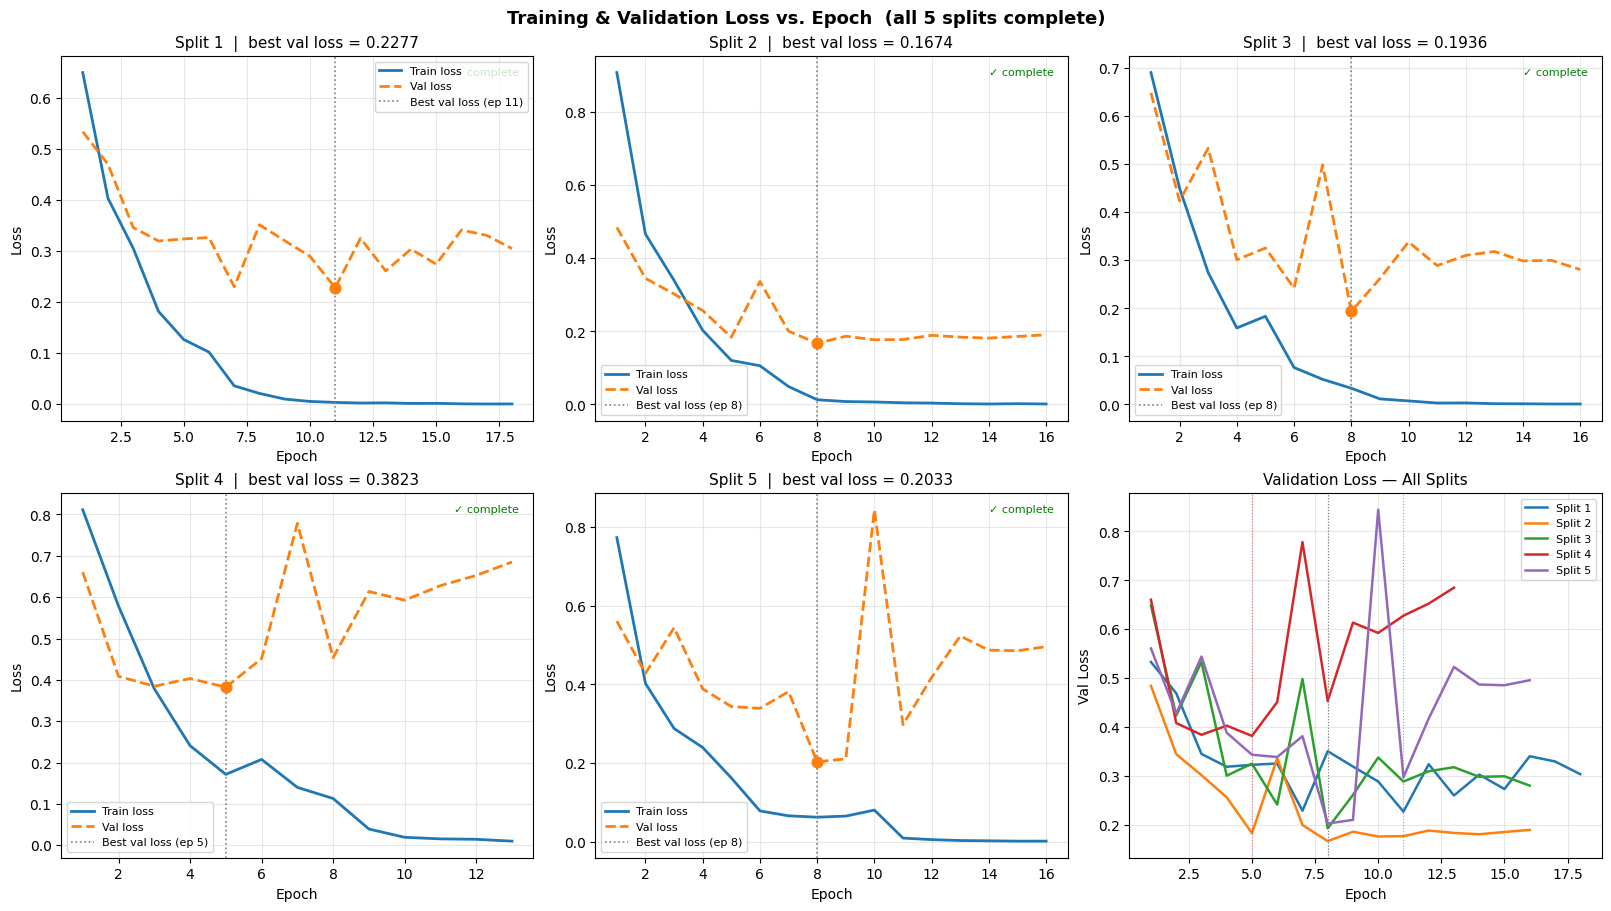

Saved: loss_curves.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.flatten()

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Subplots 0-4: one per split
for i, split in enumerate(SPLITS):
    ax = axes[i]
    records = split_data[split["label"]]
    if not records:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(split["label"])
        continue

    epochs     = [r[0] for r in records]
    train_loss = [r[1] for r in records]
    val_loss   = [r[2] for r in records]

    ax.plot(epochs, train_loss, label="Train loss", color=COLORS[0], linewidth=2)
    ax.plot(epochs, val_loss,   label="Val loss",   color=COLORS[1], linewidth=2, linestyle="--")

    best_ep = split["best_epoch"]
    best_vl = split["best_val_loss"]
    ax.axvline(best_ep, color="grey", linestyle=":", linewidth=1.2,
               label=f"Best val loss (ep {best_ep})")
    if best_ep in epochs:
        ax.scatter([best_ep], [val_loss[epochs.index(best_ep)]], color=COLORS[1], zorder=5, s=60)

    ax.set_title(f"{split['label']}  |  best val loss = {best_vl:.4f}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.text(0.97, 0.97, "✓ complete", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="green")

# Subplot 5: overlay of all splits on val loss
ax_all = axes[5]
for i, split in enumerate(SPLITS):
    records = split_data[split["label"]]
    if not records:
        continue
    epochs   = [r[0] for r in records]
    val_loss = [r[2] for r in records]
    ax_all.plot(epochs, val_loss, label=split["label"], color=COLORS[i], linewidth=1.8)
    ax_all.axvline(split["best_epoch"], color=COLORS[i], linestyle=":", linewidth=0.8, alpha=0.6)

ax_all.set_title("Validation Loss — All Splits", fontsize=11)
ax_all.set_xlabel("Epoch")
ax_all.set_ylabel("Val Loss")
ax_all.legend(fontsize=8)
ax_all.grid(alpha=0.3)

fig.suptitle("Training & Validation Loss vs. Epoch  (all 5 splits complete)",
             fontsize=13, fontweight="bold")
plt.savefig(f"{RUN_DIR}/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_curves.png")

## 4 · Deviation Plots 

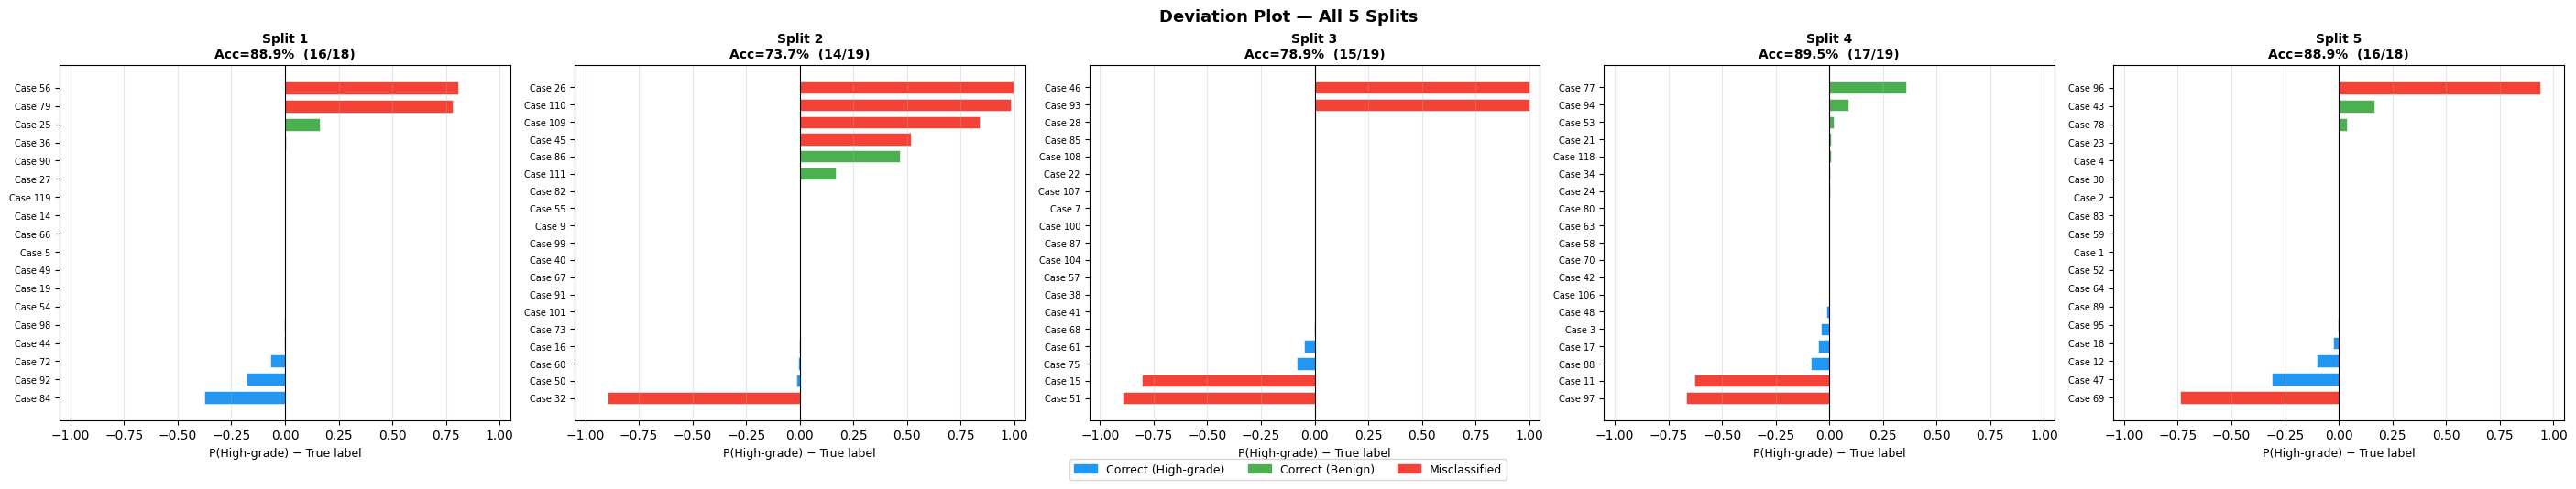


Split 1 misclassified (2 cases):
 case_id  true_label  predicted_label  prob_class1  deviation type
      56           0                1     0.807626   0.807626   FP
      79           0                1     0.779460   0.779460   FP

Split 2 misclassified (5 cases):
 case_id  true_label  predicted_label  prob_class1  deviation type
      26           0                1     0.997618   0.997618   FP
      32           1                0     0.105643  -0.894357   FN
      45           0                1     0.518084   0.518084   FP
     109           0                1     0.838805   0.838805   FP
     110           0                1     0.981961   0.981961   FP

Split 3 misclassified (4 cases):
 case_id  true_label  predicted_label  prob_class1  deviation type
      15           1                0     0.195183  -0.804817   FN
      46           0                1     0.999980   0.999980   FP
      51           1                0     0.104491  -0.895509   FN
      93           0       

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5), constrained_layout=True)

for ax, split in zip(axes, SPLITS):
    preds_path = f"{split['run_dir']}/predictions.csv"
    if not os.path.exists(preds_path):
        ax.text(0.5, 0.5, "No predictions.csv", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(split["label"])
        continue

    df = pd.read_csv(preds_path)
    y_true   = df["true_label"].values
    prob1    = df["prob_class1"].values
    correct  = df["correct"].values
    case_ids = df["case_id"].values

    deviation = prob1 - y_true
    order       = np.argsort(deviation)
    dev_sorted  = deviation[order]
    cid_sorted  = case_ids[order]
    ok_sorted   = correct[order]
    true_sorted = y_true[order]

    colors = []
    for ok, tl in zip(ok_sorted, true_sorted):
        if ok:
            colors.append("#2196F3" if tl == 1 else "#4CAF50")
        else:
            colors.append("#F44336")

    ax.barh(
        y=[f"Case {c}" for c in cid_sorted],
        width=dev_sorted,
        color=colors,
        edgecolor="white",
        linewidth=0.4,
        height=0.7,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("P(High-grade) − True label", fontsize=9)

    n_correct = correct.sum()
    acc = n_correct / len(correct)
    ax.set_title(f"{split['label']}\nAcc={acc:.1%}  ({n_correct}/{len(correct)})", fontsize=10, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", labelsize=7)

legend_patches = [
    mpatches.Patch(color="#2196F3", label="Correct (High-grade)"),
    mpatches.Patch(color="#4CAF50", label="Correct (Benign)"),
    mpatches.Patch(color="#F44336", label="Misclassified"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Deviation Plot — All 5 Splits", fontsize=13, fontweight="bold")
plt.show()

# Print misclassified cases per split
for split in SPLITS:
    preds_path = f"{split['run_dir']}/predictions.csv"
    if not os.path.exists(preds_path):
        continue
    df = pd.read_csv(preds_path)
    mis = df[df["correct"] == False].copy()
    mis["deviation"] = mis["prob_class1"] - mis["true_label"]
    mis["type"] = mis["true_label"].map({0: "FP", 1: "FN"})
    print(f"\n{split['label']} misclassified ({len(mis)} cases):")
    if len(mis):
        print(mis[["case_id", "true_label", "predicted_label", "prob_class1", "deviation", "type"]].to_string(index=False))
    else:
        print("  None")